# Clustering in Latent Space (Autoencoder + KMeans)

Epoch 1, Loss: 0.0409
Epoch 2, Loss: 0.0235
Epoch 3, Loss: 0.0189
Epoch 4, Loss: 0.0175
Epoch 5, Loss: 0.0132


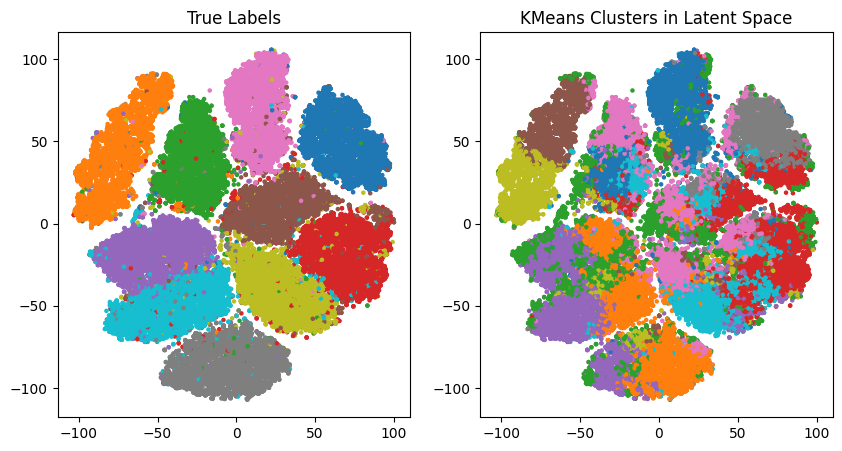

In [17]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import numpy as np

# 1. Load MNIST
transform = transforms.ToTensor()
train_data = torchvision.datasets.MNIST(root='/home/monsley/Downloads/online/GenAI/26072025/SOM/data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)

# 2. Define Autoencoder
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 32)  # Latent space: 32 dims
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),  # For pixel output in [0,1]
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

# 3. Train Autoencoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):  # Keep it short for demo
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        x_hat, _ = model(imgs)
        loss = criterion(x_hat, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# 4. Extract Latent Vectors
model.eval()
latents, labels = [], []
with torch.no_grad():
    for imgs, lbls in train_loader:
        imgs = imgs.to(device)
        _, z = model(imgs)
        latents.append(z.cpu())
        labels.append(lbls)
latents = torch.cat(latents).numpy()
labels = torch.cat(labels).numpy()

# 5. Apply KMeans on latent space
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(latents)

# 6. Visualize using TSNE or PCA
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
latent_2d = tsne.fit_transform(latents)

plt.figure(figsize=(10, 5))

# Plot original labels
plt.subplot(1, 2, 1)
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap='tab10', s=5)
plt.title("True Labels")

# Plot KMeans clusters
plt.subplot(1, 2, 2)
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=clusters, cmap='tab10', s=5)
plt.title("KMeans Clusters in Latent Space")

plt.show()


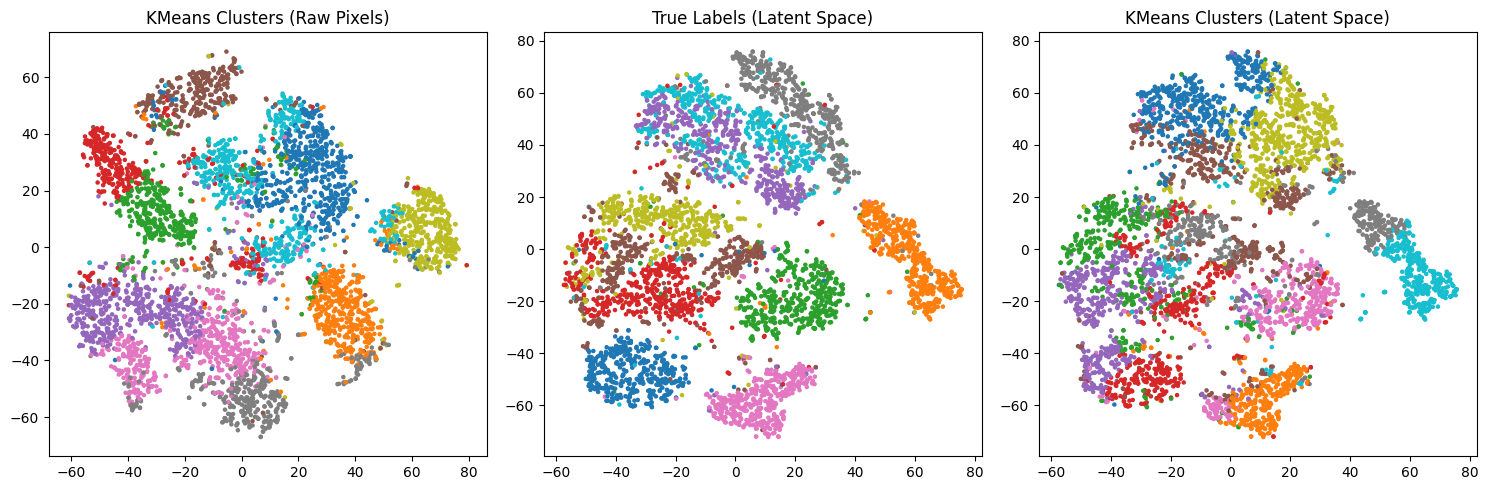

In [5]:
# ---- KMeans Clustering on both ----
kmeans_raw = KMeans(n_clusters=10, random_state=42).fit(raw_imgs)
kmeans_latent = KMeans(n_clusters=10, random_state=42).fit(latents)

# ---- TSNE Projections ----
tsne_raw = TSNE(n_components=2, perplexity=30, random_state=42)
raw_2d = tsne_raw.fit_transform(raw_imgs[:5000])  # Limit to 5000 for faster t-SNE

tsne_latent = TSNE(n_components=2, perplexity=30, random_state=42)
latent_2d = tsne_latent.fit_transform(latents[:5000])

# ---- Corresponding cluster labels ----
clusters_raw = kmeans_raw.labels_[:5000]
clusters_latent = kmeans_latent.labels_[:5000]
true_labels = labels[:5000]

# ---- Plot ----
plt.figure(figsize=(15, 5))

# 1. KMeans on raw pixels
plt.subplot(1, 3, 1)
plt.scatter(raw_2d[:, 0], raw_2d[:, 1], c=clusters_raw, cmap='tab10', s=5)
plt.title("KMeans Clusters (Raw Pixels)")

# 2. True Labels (as reference)
plt.subplot(1, 3, 2)
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=true_labels, cmap='tab10', s=5)
plt.title("True Labels (Latent Space)")

# 3. KMeans on Latent Vectors
plt.subplot(1, 3, 3)
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=clusters_latent, cmap='tab10', s=5)
plt.title("KMeans Clusters (Latent Space)")

plt.tight_layout()
plt.show()

In [ ]:
Raw pixel features (e.g., 784D)
Latent features (e.g., 32D from encoder output)

In [ ]:
| Metric                                      | Interpretation                                                                          |
| ------------------------------------------- | --------------------------------------------------------------------------------------- |
| **Adjusted Rand Index (ARI)**               | Measures similarity between clusters and true labels (adjusted for chance)              |
| **Normalized Mutual Information (NMI)**     | Measures how much information is shared between clusters and labels                     |
| **Silhouette Score**                        | How well-separated and compact the clusters are (higher = better), **no labels needed** |
| **Clustering Accuracy (Hungarian-matched)** | Maps cluster labels to true labels for max accuracy                                     |


In [4]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA

from scipy.optimize import linear_sum_assignment
import numpy as np

def cluster_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    D = max(y_pred.max(), y_true.max()) + 1
    confusion = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size):
        confusion[y_pred[i], y_true[i]] += 1

    row_ind, col_ind = linear_sum_assignment(-confusion)
    return confusion[row_ind, col_ind].sum() / y_pred.size

# Get Raw Pixel Features (784D)
raw_imgs = []
for imgs, _ in train_loader:
    raw_imgs.append(imgs.view(imgs.size(0), -1))  # Flatten to [batch, 784]
raw_imgs = torch.cat(raw_imgs).numpy()

# Run KMeans on raw and latent
kmeans_raw = KMeans(n_clusters=10, random_state=42).fit(raw_imgs)
kmeans_latent = KMeans(n_clusters=10, random_state=42).fit(latents)

# Metrics
print("===== KMeans on RAW PIXELS =====")
print("ARI:", adjusted_rand_score(labels, kmeans_raw.labels_))
print("NMI:", normalized_mutual_info_score(labels, kmeans_raw.labels_))
print("Silhouette:", silhouette_score(raw_imgs, kmeans_raw.labels_))

print("\n===== KMeans on LATENT VECTORS =====")
print("ARI:", adjusted_rand_score(labels, kmeans_latent.labels_))
print("NMI:", normalized_mutual_info_score(labels, kmeans_latent.labels_))
print("Silhouette:", silhouette_score(latents, kmeans_latent.labels_))


===== KMeans on RAW PIXELS =====
ARI: 9.64126857266233e-06
NMI: 0.0002969234325937247
Silhouette: 0.055917643

===== KMeans on LATENT VECTORS =====
ARI: 0.2750037043883338
NMI: 0.40581033903034
Silhouette: 0.11931702


In [ ]:
| Metric         | Value      | Interpretation                                           |
| -------------- | ---------- | -------------------------------------------------------- |
| **ARI**        | `~0.00001` | Nearly zero — clusters don't match true labels at all.   |
| **NMI**        | `~0.0003`  | No shared information between true classes and clusters. |
| **Silhouette** | `~0.056`   | Clusters are poorly separated and overlapping.           |

| Metric         | Value   | Interpretation                                                      |
| -------------- | ------- | ------------------------------------------------------------------- |
| **ARI**        | `0.275` | Moderate agreement with actual class labels. Significant structure. |
| **NMI**        | `0.406` | Shared information between learned clusters and true labels.        |
| **Silhouette** | `0.119` | Clusters are more compact and better separated.                     |


In [6]:
print("Accuracy (Raw):", cluster_accuracy(labels, kmeans_raw.labels_))
print("Accuracy (Latent):", cluster_accuracy(labels, kmeans_latent.labels_))

Accuracy (Raw): 0.10605
Accuracy (Latent): 0.46935


In [ ]:
| Source                         | Accuracy  | Interpretation                                                                                                                                             |
| ------------------------------ | --------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Raw Pixels**                 | **0.106** | Almost like random guessing (10 classes → \~10%) — because raw pixel space is high-dimensional, sparse, and not semantically meaningful.                   |
| **Latent Space (Autoencoder)** | **0.469** | Nearly **5× better** — the autoencoder has compressed the data into a **semantically structured representation** where similar digits are closer together. |


# AUTOENCODER as a DENOISER!!!  
Denoising the data

In [8]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Load MNIST
#transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='/home/monsley/Downloads/online/GenAI/26072025/SOM/data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='/home/monsley/Downloads/online/GenAI/26072025/SOM/data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True)

def add_noise(inputs, noise_factor=0.5):
    noisy = inputs + noise_factor * torch.randn_like(inputs)
    return torch.clamp(noisy, 0., 1.)

class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = DenoisingAutoencoder().to('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

device = next(model.parameters()).device

for epoch in range(5):  # Keeping it short for demo GENAI CLASS!
    for imgs, _ in train_loader:
        noisy_imgs = add_noise(imgs).to(device)
        clean_imgs = imgs.to(device)
        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")




Epoch 1, Loss: 0.0562
Epoch 2, Loss: 0.0372
Epoch 3, Loss: 0.0338
Epoch 4, Loss: 0.0282
Epoch 5, Loss: 0.0278


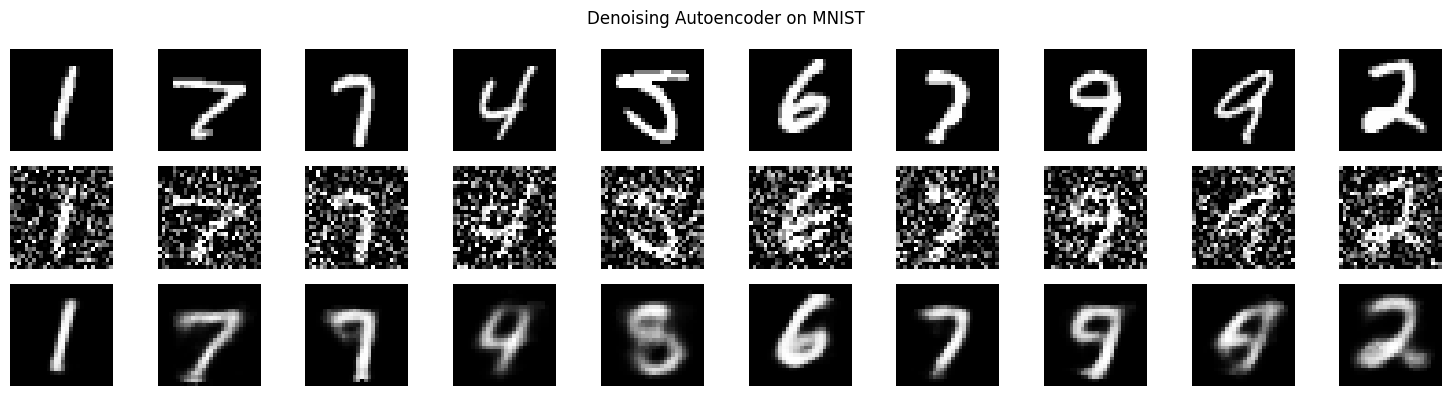

In [9]:
# Get sample batch from test set
test_imgs, _ = next(iter(test_loader))
noisy_test_imgs = add_noise(test_imgs).to(device)
cleaned_imgs = model(noisy_test_imgs).cpu().detach()

# Plot
fig, axes = plt.subplots(3, 10, figsize=(15, 4))
for i in range(10):
    axes[0, i].imshow(test_imgs[i][0], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(noisy_test_imgs[i].cpu()[0], cmap='gray')
    axes[1, i].axis('off')
    axes[2, i].imshow(cleaned_imgs[i][0], cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Noisy")
axes[2, 0].set_ylabel("Denoised")
plt.suptitle("Denoising Autoencoder on MNIST")
plt.tight_layout()
plt.show()


In [ ]:
# Applications: OCR noise reduction, medical image cleaning, industrial visual QC, IoT sensors

# Similarity Search using Latent Space from Autoencoder 

In [ ]:
Given a query image, compute its latent vector and find nearest neighbors (top-5) using Euclidean or cosine similarity.

Show that semantically similar images cluster in latent space

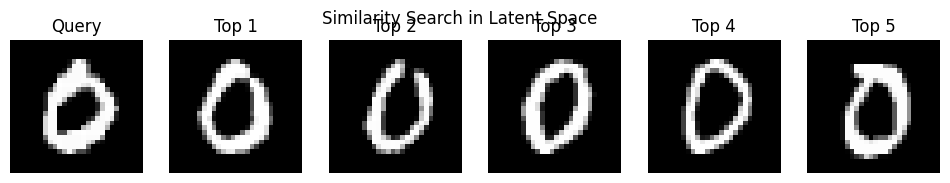

In [20]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Get test batch (say 1000 samples)
n_samples = 1000
test_subset = torch.utils.data.Subset(test_dataset, range(n_samples))
test_loader_subset = DataLoader(test_subset, batch_size=n_samples, shuffle=False)
test_imgs, _ = next(iter(test_loader_subset))
test_imgs = test_imgs.to(device)

# Encode all test images to latent space
with torch.no_grad():
    latent_vectors = model.encoder(test_imgs).cpu()

# Choose a query image (say index 0)
query_index = 3
query_img = test_imgs[query_index].unsqueeze(0)
query_latent = model.encoder(query_img).cpu()

# Compute cosine similarity with all latent vectors
similarities = F.cosine_similarity(query_latent, latent_vectors)
top_k = torch.topk(similarities, k=6)  # top 6 includes the query itself

top_indices = top_k.indices.numpy()

# Plot query + top-5 similar images
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i, idx in enumerate(top_indices):
    axes[i].imshow(test_imgs[idx].cpu().squeeze(), cmap='gray')
    axes[i].axis('off')
    if i == 0:
        axes[i].set_title("Query")
    else:
        axes[i].set_title(f"Top {i}")
plt.suptitle("Similarity Search in Latent Space")
plt.show()


#  Image inpainting (missing data imputation)

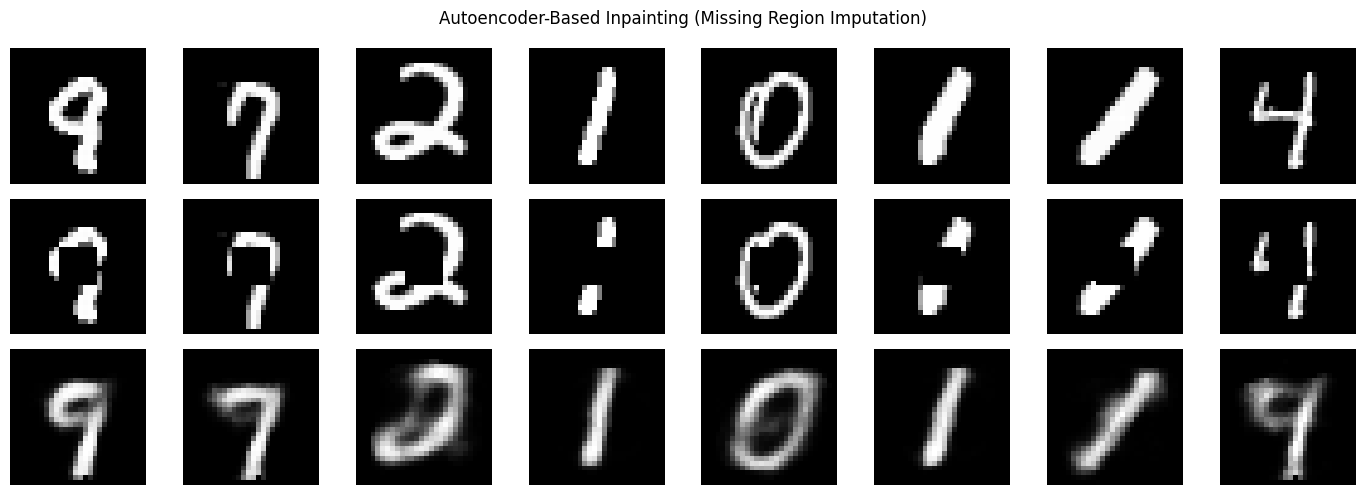

In [14]:
import torch
import matplotlib.pyplot as plt

# Get some test images
examples = enumerate(test_loader)
batch_idx, (example_data, _) = next(examples)
example_data = example_data[:8].to(device)

# Create a masked version (center square removed)
masked_data = example_data.clone()
masked_data[:, :, 10:18, 10:18] = 0  # zero out center region

# Reconstruct using autoencoder
with torch.no_grad():
    output = model(masked_data)

# Plot original, masked, and reconstructed
fig, axes = plt.subplots(3, 8, figsize=(14, 5))

for i in range(8):
    axes[0, i].imshow(example_data[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_ylabel("Original")
    
    axes[1, i].imshow(masked_data[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_ylabel("Masked")
    
    axes[2, i].imshow(output[i].cpu().squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_ylabel("Reconstructed")

plt.suptitle("Autoencoder-Based Inpainting (Missing Region Imputation)")
plt.tight_layout()
plt.show()


In [ ]:
| Reason                    | Explanation                                                                                                                                                                            |
| ------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Contextual Encoding**   | The encoder uses available parts (edges, curves) to infer what the full object likely is. E.g., if a digit has curves like a 3, the decoder fills in the missing part to complete a 3. |
| **Data Prior**            | The decoder has learned a *prior* on the structure of digits (or other data), and uses this to "guess" missing areas.                                                                  |
| **Distribution Learning** | The autoencoder has internalized the data distribution, so it can *hallucinate* missing portions that are **statistically consistent** with the rest of the image.                     |

# Autoencoder for Data Compression 

In [15]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# CIFAR-10 Loader
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='/home/monsley/Downloads/online/GenAI/26072025/SOM/data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True)

# Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*32*3, 1024),
            nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 32*32*3),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon.view(-1, 3, 32, 32), z

model = Autoencoder(latent_dim=64)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train for 5 epochs for demo
for epoch in range(5):
    for img, _ in trainloader:
        recon, _ = model(img)
        loss = criterion(recon, img)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 1, Loss: 0.0142
Epoch 2, Loss: 0.0120
Epoch 3, Loss: 0.0115
Epoch 4, Loss: 0.0106
Epoch 5, Loss: 0.0101


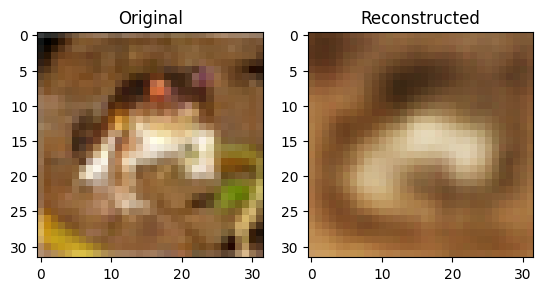

In [16]:
import numpy as np

# Take 1 sample image
sample_img, _ = trainset[0]
sample_img = sample_img.unsqueeze(0)

# Forward pass
with torch.no_grad():
    recon_img, latent = model(sample_img)

# Plot
plt.subplot(1, 2, 1)
plt.imshow(sample_img.squeeze().permute(1, 2, 0))
plt.title("Original")
plt.subplot(1, 2, 2)
plt.imshow(recon_img.squeeze().permute(1, 2, 0))
plt.title("Reconstructed")
plt.show()


In [ ]:
Quantify Compression Rate
Raw Image Size:

    32×32×3 = 3072 floats
    Assuming 32-bit floats = 3072 × 4 bytes = 12.3 KB

Latent Representation Size:

    Latent dim = 64
    64 × 4 bytes = 256 bytes

Decoder Size (Assume Fixed)

    Decoder weights ≈ 1024×64 + 3072×1024 = ~3.2 million parameters (approx 13 MB)
    But it’s shared — used for all samples

In [ ]:
# Compression ration should be around = 3072/64 = That means you're storing 1/48th the size per image!

In [ ]:
# Real-World Applications of Autoencoders (AE)

---
## 1. Anomaly Detection

**Use Case:** Train AE on normal data. Reconstruction error rises on anomalous data.

**Industries:**
- Finance: Credit card fraud detection
- Manufacturing: Equipment fault detection from sensor data
- Cybersecurity: Network intrusion detection

---
## 2. Image Denoising / Enhancement

**Use Case:** Denoising Autoencoder removes noise from input image.

**Industries:**
- Healthcare: Clean low-dose CT, MRI scans
- Mobile apps: Snapchat/Instagram filters
- Remote sensing: Satellite image cleanup

---
## 3. Compression & Representation Learning

**Use Case:** Latent vector serves as a compressed form of data.

**Industries:**
- Edge AI / IoT: Compress sensor data before transmission
- Self-driving cars: Compress camera input
- Cloud storage: Efficient encoding of high-dimensional data

---
## 4. Medical Imaging

**Use Case:** AE learns to reconstruct medical images from compressed forms.

**Industries:**
- Radiology: MRI/X-ray image reconstruction
- Telemedicine: Compress scans for remote diagnosis
- Healthcare AI: Fill missing scan data (inpainting)

---
## 5. Generative Design & Data Augmentation (VAE)

**Use Case:** VAE generates new but realistic samples.

**Industries:**
- Drug discovery: Generate molecular structures
- Fashion: Create new clothing designs
- Gaming: Synthesize character faces or objects

---
## 6.Speech & Audio Processing

**Use Case:** Denoise audio or compress speech data.

**Industries:**
- Video conferencing: Clean up voice (Zoom, MS Teams)
- Music: Latent-space music generation
- Accessibility tools: Voice clarity enhancement

---
## 7.Log & Text Anomaly Detection

**Use Case:** Use AE on text embeddings (e.g., BERT + AE) to detect abnormal patterns.

**Industries:**
- DevOps: Detect unusual system logs
- FinTech: Monitor transaction sequences
- SaaS: Application health monitoring

---
## 8.Pretraining for Low-Label Settings

**Use Case:** Use AE as unsupervised pretraining; fine-tune with labeled data.

**Industries:**
- Healthcare AI
- Industrial ML pipelines
- NLP tasks with limited labels

---

## Just a Summary

| Use Case             | Autoencoder Type | Industry           | Benefit                        |
|----------------------|------------------|--------------------|-------------------------------|
| Anomaly Detection    | AE               | Finance, IoT       | Detect rare events            |
| Image Denoising      | Denoising AE     | Healthcare, Apps   | Remove noise, enhance quality |
| Compression          | AE/VAE           | Edge, Cloud, IoT   | Reduce storage/transmission   |
| Generative Design    | VAE              | Pharma, Fashion    | Create new designs or samples |
| Audio Cleanup        | Denoising AE     | Conferencing, Music| Clearer audio                 |
| Log Monitoring       | AE               | DevOps, FinTech    | Detect abnormal logs          |

---
